## Deep Q-Network (DQN)
En lugar de discretizar el espacio de estados como en SARSA y Q-learning, vamos a 
usar **Deep Q-Learning (DQL)**.

La idea es sustituir la Q-table por una **red neuronal** que aproxima la función Q 
para cada par estado-acción. Esto nos permite:

- Trabajar directamente con las 18 observaciones continuas del entorno, sin discretizar
- Generalizar a estados no vistos durante el entrenamiento
- Escalar a problemas con espacios de estados grandes

El algoritmo requiere tres componentes:
- `Transition`: estructura de datos para guardar una transición
- `Memory`: búfer de reproducción (replay buffer)
- `DQNAgent`: agente con red neuronal, política epsilon-greedy y entrenamiento por 
descenso del gradiente

## Transition y Memory (Replay Buffer)

In [1]:
import random
from collections import deque
from typing import Any, List, NamedTuple, Sequence, SupportsFloat, Union


class Transition(NamedTuple):
    """Representa la transición de un estado al siguiente."""
    prev_state: Any
    next_state: Any
    action: Any
    reward: SupportsFloat
    terminated: bool


class Memory:
    """Búfer de reproducción (replay buffer) de tamaño fijo, lo usamos para que el agente no entrene con experiencias en orden cronológico
    que introducirían correlaciones que desestabilizarian el entrenamiento"""

    def __init__(self, size: int):
        self.max_size = int(size)
        self.transitions: deque = deque(maxlen=self.max_size) #inicializamos una cola con el tamaño máximo fijo

    def remember(self, transition: Transition):
        self.transitions.append(transition) # guardamos una transición

    def batch(self, n: int) -> List[Transition]:
        n = min(len(self.transitions), n)
        return random.sample(self.transitions, n) #extrae una muestra aleatoria de n transiciones

    def __len__(self) -> int:
        return len(self.transitions) # lo usamos para comprobar si el batch tiene n transiciones

    def __getitem__(self, key: Union[int, slice]) -> Union[Transition, Sequence[Transition]]:
        return self.transitions.__getitem__(key) # para acceder al buffer ya sea a una sola transicion o a un conjunto de ellas.


## DQN Agent

La ecuación de Bellman adaptada a DQL es la función de pérdida que minimizamos:

$$L(\theta) = \left( r + \gamma \max_{a'} Q(s', a'; \theta) - Q(s, a; \theta) \right)^2$$

Se usa una capa oculta de 64 neuronas en lugar de 128 para mantener coherencia 
arquitectónica con el Dueling DQN, que demostró empíricamente mejor rendimiento 
con esta configuración en este entorno.

La red neuronal recibe el estado (18 valores continuos) y devuelve un Q-value por cada acción (7 acciones).

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


class QNetwork(nn.Module):
    """Red neuronal que aproxima la función Q.
    Entrada: estado (18 valores continuos)
    Salida: Q-value para cada acción (7 valores)
    """

    def __init__(self, n_obs, n_actions):
        super().__init__()
        self.net = nn.Sequential( #definimos una red neuronal sequencial
            nn.Linear(n_obs, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        ) # no tenemos activación final para no limitar las acciones que se toman. 

    def forward(self, x):
        return self.net(x) # propagacion 


class DQNAgent:
    """
    Agente Deep Q-Learning.
    Usa una red neuronal como aproximador de Q en lugar de una tabla.
    Entrena minimizando el MSE de la ecuación de Bellman mediante descenso del gradiente.
    """

    def __init__(self, n_obs, n_actions, gamma, lr, batch_size,
                 memory_size, epsilon, epsilon_min, epsilon_decay):
        self.n_actions = n_actions
        self.gamma = gamma # factor de descuento, cuanto valora el agente el futuro vs el presente
        self.batch_size = batch_size # tamaño de batch, controla la memoria que se usa para entrenar
        self.epsilon = epsilon #parametros para E-greedy 
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.memory = Memory(size=memory_size) # instanciamos el replay buffer como referencia, si hacemos 2000 episodio x 300 pasos por episodio
        # en total tendríamos unas 600.000 transiciones. Conforme vamos avanzo el entrenamiento las transiciones malas se van yendo de la cola por así decirlo.
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = QNetwork(n_obs, n_actions).to(self.device) #crea red neuronal
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr) #ajuste de los parámetros de la red
        self.loss_fn = nn.MSELoss() #error cuadrático medio(lo que hay ue minimizar)

    def select_action(self, state):
        """Política epsilon-greedy:"""
        if random.random() < self.epsilon: # con probabilidad epsilon, elegimos una acción aleatoria
            return random.randrange(self.n_actions)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)  # convertimos el estado a tensor y añadimos dimension 
        with torch.no_grad():
            q_values = self.model(state_t) # desactivamos el calculo de gradientes ya que aqui solo queremos inferir 
            
        return int(q_values.argmax().item()) # inferimos la accion de mayor valor 

    def learn(self):
        """Un paso de entrenamiento: muestrea un batch y minimiza el MSE de Bellman."""
        if len(self.memory) < self.batch_size:
            return # no entrena hasta tener suficientes experiencias acumuladas
        batch = self.memory.batch(self.batch_size) # inicializamos el batch con transiciones aleatorias
        #desenpaquetamos el batch en tensores separados por tipo
        prev_states = torch.FloatTensor(np.array([t.prev_state for t in batch])).to(self.device)
        next_states = torch.FloatTensor(np.array([t.next_state for t in batch])).to(self.device)
        actions     = torch.LongTensor([t.action for t in batch]).to(self.device)
        rewards     = torch.FloatTensor([t.reward for t in batch]).to(self.device)
        terminated  = torch.BoolTensor([t.terminated for t in batch]).to(self.device)

        qs = self.model(prev_states).gather(1, actions.unsqueeze(1)).squeeze(1) #predecimos q-values para los estados anteriores

        with torch.no_grad():#calculamos lo que debería de haber predicho 
            next_qs = self.model(next_states).max(1).values #cogemos el mejor q-value del siguiente estado 
            next_qs[terminated] = 0.0 #el ultimo sería 0.0 porque el episodio termina
            targets = rewards + self.gamma * next_qs # ecuación del bellman 
 
        # calculamos el descenso de gradiente
        loss = self.loss_fn(qs, targets) #ajustamos los pesos MSE entre qs y targets
        self.optimizer.zero_grad() # borramos gradientes del paso anterior 
        loss.backward() #calculamos cuánto contribuye cada peso al error (backpropagation)
        nn.utils.clip_grad_norm_(self.model.parameters(), 10.0)
        self.optimizer.step() # movemos los pesos en la dirección correcta

    def decay_epsilon(self): # reducimos el epsilon en cada epsidio pero nunca por debajo del minimo
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, path): # guardamos los pesos de la arquitectura(modelo)
        torch.save(self.model.state_dict(), path)

    def load(self, path): # cargamos los pesos de la arquitectura
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.eval()


## Entrenamiento DQN

El bucle de entrenamiento implementa los siguientes mecanismos:

- **Warmup** (`warmup_steps=5000`): se llena el replay buffer con experiencias 
aleatorias antes de empezar a aprender, para garantizar diversidad en los primeros batches
- **Frecuencia de aprendizaje**: `learn()` se llama cada 4 pasos en lugar de cada paso, 
reduciendo coste computacional y permitiendo que entren nuevas experiencias entre actualizaciones
- **Detección de atasco**: si el agente no se desplaza más de 0.05 m durante 20 pasos 
consecutivos, el episodio se termina forzosamente para evitar llenar el buffer con 
experiencias poco informativas


In [ ]:
import os
import sys
import pandas as pd
from tqdm import tqdm
sys.path.append(os.path.abspath(".."))
from envs.continuous_parking_env import ContinuousParkingEnv
from IPython.display import clear_output

def train_dqn(episodes=7000, max_steps=300, warmup_steps=5000, gamma=0.99,
              lr=5e-4, batch_size=128, memory_size=60_000,
              epsilon=1.0, epsilon_min=0.1, epsilon_decay=0.999):
    env = ContinuousParkingEnv(render_mode=None) #creamos el entorno
    agent = DQNAgent( #creamos el agente
        n_obs=env.observation_space.shape[0],
        n_actions=env.action_space.n,
        gamma=gamma, lr=lr, batch_size=batch_size, memory_size=memory_size,
        epsilon=epsilon, epsilon_min=epsilon_min, epsilon_decay=epsilon_decay,
    )

    # --- warmup ---
    obs, _ = env.reset() # llenamos el buffer con experiencias aleatorias para que las primeras iteraciones 
    # del learn no estén sesgadas
    for _ in range(warmup_steps):
        action = env.action_space.sample() #eligimos una acción clompletamente aleatoria 
        next_obs, reward, terminated, truncated, _ = env.step(action) # ejecutamos la accion recibiendo recompensa
        agent.memory.remember(Transition(
            prev_state=obs, next_state=next_obs,
            action=action, reward=reward, terminated=terminated,
        )) #guardamos la transición en el buffer
        obs = next_obs
        if terminated or truncated:
            obs, _ = env.reset() #si el episodio terminó, reseteamos el entorno para avanzar a un estado nuevo

    # --- Bucle principal ---
    results = [] # aquí guardaremos las metricas de cada episodio para después generar un csv

    for episode in tqdm(range(episodes), desc="Training DQN"): # por cada episodio 
        obs, info = env.reset() # reseteamos el entorno y las métricas
        total_reward = 0.0
        success = False
        collision = False
         # Control de atasco
        last_x, last_y = info["x"], info["y"]   # coordenadas reales
        stuck_steps = 0

        for step in range(max_steps): # por cada paso que da el agente
            action = agent.select_action(obs) # elegimos la acción de mayor valor(politica e-greedy)
            next_obs, reward, terminated, truncated, info = env.step(action) # la ejecutamos y recibimos información del entorno
            done = terminated or truncated
            
            # Detectar atasco: si no se mueve más de 0.05 en x ni en y durante 20 steps
            if abs(info["x"] - last_x) < 0.05 and abs(info["y"] - last_y) < 0.05:
                stuck_steps += 1
            else:
                stuck_steps = 0
                last_x, last_y = info["x"], info["y"]

            if stuck_steps >= 20:
                done = True

            agent.memory.remember(Transition(
                prev_state=obs, next_state=next_obs,
                action=action, reward=reward, terminated=terminated,
            )) # guardamos la transicion el el buffer de experiencia
            
            if step % 4 == 0:
                agent.learn()# realiza un paso de entrenamiento con un batch aleatorio
            obs = next_obs # avanzamos el estado actual
            total_reward += reward # acumulamos recompensa por episodio 

            if info["is_success"]: # marcamos si hubo éxito o colisiono en algún momento 
                success = True
            if info["collision"]:
                collision = True

            if done: # salimos del bucle si termino
                break

        agent.decay_epsilon() # reducimos el epsilon al final de cada episodio

        results.append({
            "episode": episode, "reward": total_reward,
            "success": int(success), "collision": int(collision),
            "steps": step + 1, "epsilon": agent.epsilon,
            "final_distance": info["distance_to_goal"],
        }) #guardamos las métricas del episodio 
        
        if episode % 10 == 0:
            clear_output(wait=True)
            print(f"Episode {episode} | dist: {info['distance_to_goal']:.2f} | reward: {total_reward:.1f} | epsilon: {agent.epsilon:.3f}")
    env.close() # liberamos recursos del entorno 
    os.makedirs("results", exist_ok=True)
    df = pd.DataFrame(results)
    df.to_csv("results/dqn_results.csv", index=False)
    agent.save("results/dqn_model.pt")
    print("Entrenamiento terminado.")
    return agent, df


agent, df = train_dqn()

Training DQN: 100%|█████████▉| 6991/7000 [1:21:07<00:05,  1.56it/s]

Episode 6990 | dist: 0.11 | reward: 101.1 | epsilon: 0.100


Training DQN: 100%|██████████| 7000/7000 [1:21:14<00:00,  1.44it/s]


Entrenamiento terminado.


## Resultados y visualización

In [ ]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import numpy as np
from IPython.display import display, clear_output

sys.path.append(os.path.abspath(".."))
from envs.continuous_parking_env import ContinuousParkingEnv


def plot_results(nombre, window=100):
    """Visualiza las métricas de entrenamiento de un algoritmo.
    nombre: clave del CSV (ej: 'dqn', 'double_dqn', 'dueling_dqn')
    """
    df = pd.read_csv(f"results/{nombre}_results.csv")

    df["reward_ma"]         = df["reward"].rolling(window).mean()
    df["success_ma"]        = df["success"].rolling(window).mean()
    df["collision_ma"]      = df["collision"].rolling(window).mean()
    df["steps_ma"]          = df["steps"].rolling(window).mean()
    df["final_distance_ma"] = df["final_distance"].rolling(window).mean()

    titulo = nombre.replace("_", " ").upper()

    metricas = [
        ("reward",         "Recompensa",              "Recompensa por episodio",    None),
        ("success",        "Tasa de éxito",           "Tasa de éxito",             (0, 1)),
        ("collision",      "Tasa de colisión",        "Colisiones",                (0, 1)),
        ("steps",          "Pasos",                   "Pasos por episodio",        None),
        ("final_distance", "Distancia final a plaza", "Distancia final al objetivo", None),
    ]

    for col, ylabel, subtitulo, ylim in metricas:
        plt.figure(figsize=(9, 4))
        if col == "reward":
            plt.plot(df["episode"], df[col], alpha=0.25, label=ylabel)
        plt.plot(df["episode"], df[f"{col}_ma"], label=f"{ylabel} media móvil {window}")
        plt.xlabel("Episodio")
        plt.ylabel(ylabel)
        plt.title(f"{titulo} - {subtitulo}")
        if ylim:
            plt.ylim(*ylim)
        plt.legend()
        plt.grid(True)
        plt.show()


def render_inline(env):
    """Renderiza el estado actual del entorno como figura inline en Jupyter."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_xlim(0, env.world_width)
    ax.set_ylim(0, env.world_height)
    ax.set_aspect("equal")
    ax.set_title("Entorno Parking Simulado")

    for ox, oy, ow, oh in env.obstacles:
        ax.add_patch(patches.Rectangle((ox, oy), ow, oh, color="steelblue", alpha=0.6))

    ax.add_patch(patches.Rectangle(
        (env.parking_center[0] - 0.4, env.parking_center[1] - 0.6),
        0.8, 1.2, fill=False, edgecolor="black", linewidth=2
    ))

    for relative_angle in env.sensor_angles:
        ray_angle = env.theta + relative_angle
        d = env._cast_ray(ray_angle)
        ax.plot([env.x, env.x + d * np.cos(ray_angle)],
                [env.y, env.y + d * np.sin(ray_angle)],
                linestyle="--", linewidth=0.8, color="gray")

    ax.plot(env.x, env.y, "o", markersize=10, color="steelblue")
    ax.arrow(env.x, env.y, 0.4 * np.cos(env.theta), 0.4 * np.sin(env.theta),
             head_width=0.15, length_includes_head=True, color="black")
    ax.grid(True, alpha=0.3)

    clear_output(wait=True)
    display(fig)
    plt.close(fig)


def visualizar_agente(nombre, model, max_steps=300):
    """Ejecuta un episodio mostrando el comportamiento del agente en el parking.
    nombre: nombre del algoritmo (ej: 'DQN', 'Double DQN', 'Dueling DQN')
    model:  red neuronal cargada con pesos entrenados, en modo eval()
    """
    device = next(model.parameters()).device

    def select_action(obs):
        state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            return int(model(state_t).argmax().item())

    env = ContinuousParkingEnv(render_mode=None)
    obs, info = env.reset()

    print(f"\n--- Visualizando {nombre} ---")
    for step in range(max_steps):
        action = select_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        render_inline(env)
        if terminated or truncated:
            break

    status = "✅ Aparcado" if info["is_success"] else "💥 Colisión" if info["collision"] else "⏱ Tiempo agotado"
    print(f"Episodio terminado en {step+1} pasos — {status}")
    print(f"Distancia final a la plaza: {info['distance_to_goal']:.3f} m")
    env.close()


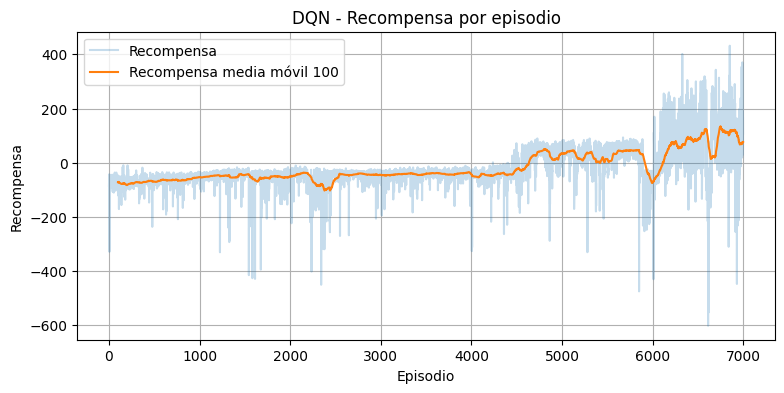

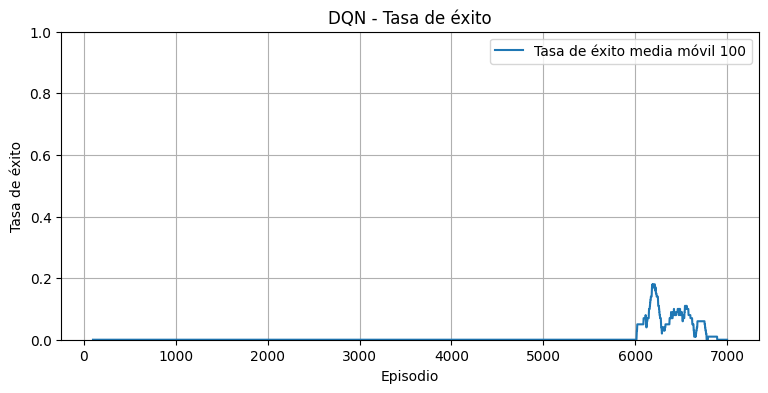

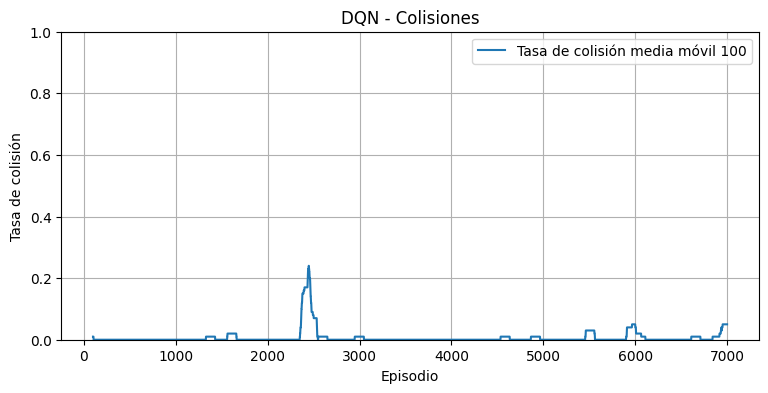

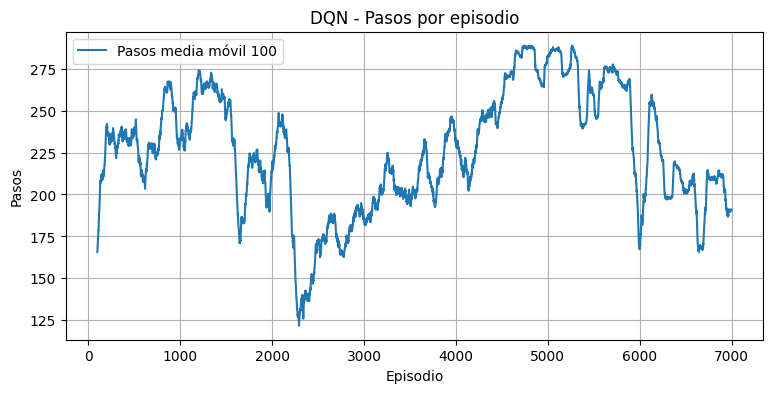

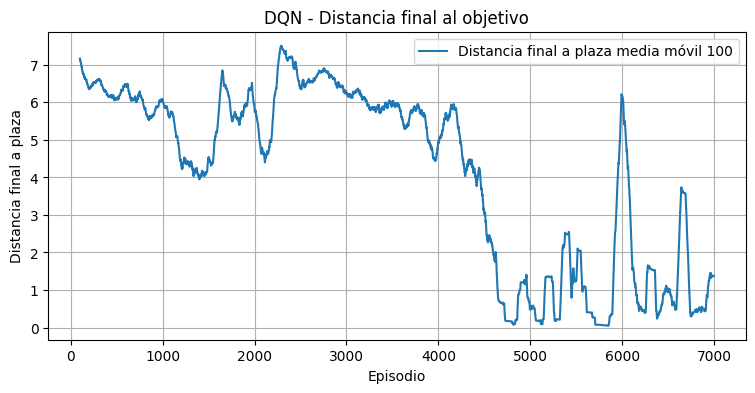

In [5]:
plot_results("dqn")

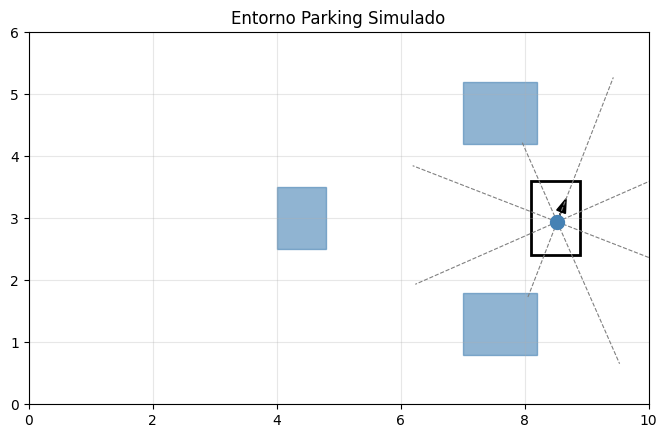

Episodio terminado en 247 pasos — ⏱ Tiempo agotado
Distancia final a la plaza: 0.063 m


In [6]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dqn = QNetwork(n_obs=18, n_actions=7).to(device)
model_dqn.load_state_dict(torch.load("results/dqn_model.pt", map_location=device))
model_dqn.eval()

visualizar_agente("DQN", model_dqn)


## Conclusiones del DQN

El DQN es el punto de partida de la familia de algoritmos de Deep Reinforcement Learning en este proyecto. Al sustituir la Q-table por una red neuronal que aproxima Q(s, a; θ) directamente sobre el vector de observación continua de 18 variables, resuelve las dos grandes limitaciones de los métodos tabulares: elimina la necesidad de discretización y permite generalizar a estados no visitados durante el entrenamiento.

Los datos de entrenamiento revelan una **convergencia real**, aunque más lenta que los algoritmos posteriores. Hasta el episodio ~4 500 el agente acumula experiencia sin resultados consistentes; a partir de ese punto el porcentaje de episodios que terminan con el vehículo a menos de 0.35 m de la plaza **salta del 10 % al ~80 %** y se mantiene ahí hasta el final. El agente ha aprendido a llegar a la plaza de forma consistente; la dificultad reside en ejecutar el frenado preciso en el momento y orientación exactos que exige la condición de éxito estricta.

En evaluación greedy, el modelo consigue aparcar con una distancia final de **0.063 m** en 247 pasos.

Sin embargo, el DQN presenta su limitación estructural más importante: la **sobreestimación de Q-values**. Al usar la misma red tanto para seleccionar la acción óptima como para evaluar su valor en el target:

$$y = r + \gamma \cdot \max_{a'} Q(s', a'; \theta)$$

se introduce un sesgo positivo sistemático que infla los valores Q y ralentiza la convergencia. Esta observación motiva directamente la implementación del **Double DQN**, donde ambas responsabilidades se desacoplan entre una red online y una red target.

---

## Tabla de Hiperparámetros — DQN

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Episodios | 7 000 | La convergencia real ocurre ~ep. 4 500; se reservan ~2 500 episodios adicionales de estabilización. |
| Pasos máximos / episodio | 300 | Permite completar una maniobra completa sin truncar prematuramente. |
| Warmup steps | 5 000 | Rellena el buffer con experiencias aleatorias diversas antes del primer aprendizaje. |
| Factor de descuento γ | 0.99 | Prioriza la recompensa futura; necesario porque aparcar requiere planificación a medio plazo. |
| Tasa de aprendizaje lr | 5 × 10⁻⁴ | Valor moderado para Adam: estable y suficientemente rápido para converger en 7 000 episodios. |
| Tamaño de batch | 128 | Reduce la varianza del gradiente manteniendo un coste computacional razonable. |
| Tamaño replay buffer | 60 000 | ~200 episodios completos; suficiente para romper correlaciones temporales. |
| ε inicial | 1.0 | Exploración total al inicio para generar experiencias diversas. |
| ε mínimo | 0.1 | Mantiene un 10 % de exploración residual para evitar óptimos locales. Aunque conlleve algo más de ruido al final, (se puede quitar) |
| ε decay | 0.999 | Decaimiento lento: ε tarda ~2 300 episodios en bajar de 1.0 a 0.1. |
| Frecuencia de aprendizaje | Cada 4 pasos | Reduce el coste computacional y permite incorporar nuevas experiencias entre actualizaciones. |
| Umbral de atasco | 20 pasos / 0.05 m | Termina el episodio si el agente no avanza, evitando llenar el buffer con transiciones poco informativas. |
| Arquitectura | 18 → 64 → 64 → 7 | Dos capas ocultas de 64 neuronas con ReLU; tamaño coherente con el Dueling DQN que demostró mejor rendimiento empírico con esta configuración. |